# Gravitational Lensing Dark Matter Classification: Baseline ResNet18

This notebook trains a baseline ResNet18 model on a common classification task for gravitational lensing data to predict dark matter substructure types.

## 1. Setup: Import Libraries and Configure Device

Import necessary libraries for deep learning, data handling, and visualization. Set up GPU/CPU device and fix random seeds for reproducibility.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision.models import ResNet18_Weights
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## 2. Load Data

Load training and test sets from Kaggle dataset. Each image is 150×150 pixels (1 channel), and labels indicate three classes: no substructure (0), spherical (1), or vortex (2).

In [2]:
DATA_DIR = './'

X_train = np.load('/kaggle/input/datasets/abhirajraje/lensing-data/X_train.npy')  # (30000, 1, 150, 150)
X_test  = np.load('/kaggle/input/datasets/abhirajraje/lensing-data/X_test.npy')   # (7500,  1, 150, 150)
y_train = np.load('/kaggle/input/datasets/abhirajraje/lensing-data/y_train.npy')  # (30000,)
y_test  = np.load('/kaggle/input/datasets/abhirajraje/lensing-data/y_test.npy')   # (7500,)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape},  y_test:  {y_test.shape}')
print(f'Classes: {np.unique(y_train)} | Counts: {np.bincount(y_train.astype(int))}')
print(f'\nData range — min: {X_train.min():.4f}, max: {X_train.max():.4f}')

X_train: (30000, 1, 150, 150), y_train: (30000,)
X_test:  (7500, 1, 150, 150),  y_test:  (7500,)
Classes: [0 1 2] | Counts: [10000 10000 10000]

Data range — min: 0.0000, max: 1.0000


## 3. Set Training Parameters

Define the total number of epochs for training.

In [3]:
TOTAL_EPOCHS = 50

## 4. Visualize Sample Images

Display one sample image from each of the three classes to understand the data distribution and characteristics.

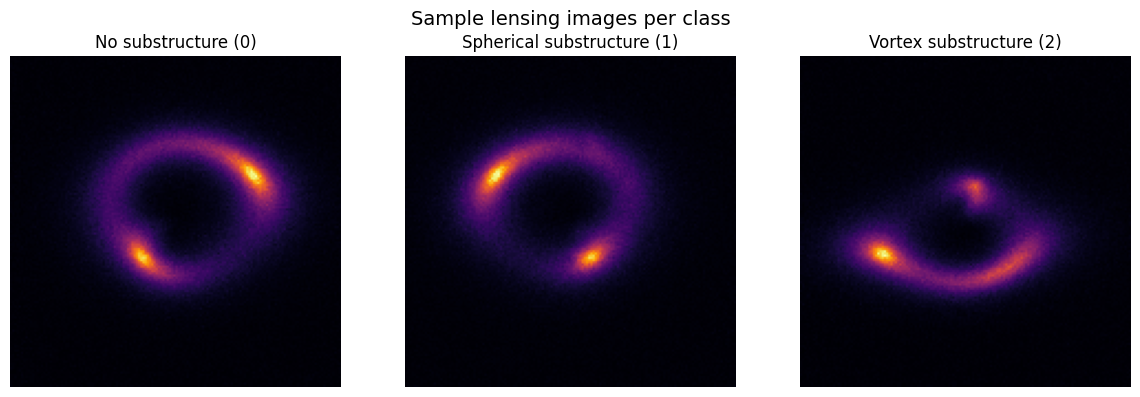

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
labels_desc = ['No substructure (0)', 'Spherical substructure (1)', 'Vortex substructure (2)']

for cls in range(3):
    idx = np.where(y_train == cls)[0][0]
    axes[cls].imshow(X_train[idx, 0], cmap='inferno')
    axes[cls].set_title(labels_desc[cls])
    axes[cls].axis('off')

plt.suptitle('Sample lensing images per class', fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Create Dataset and DataLoaders

Define custom PyTorch Dataset class with data augmentations (flips, rotations) for training. Create train and test DataLoaders with batch processing.

In [5]:
class LensingDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = self.X[idx]
        label = self.y[idx]

        if self.augment:
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[-1])
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[-2])
            k = torch.randint(0, 4, (1,)).item()
            img = torch.rot90(img, k, dims=[-2, -1])

        return img, label


train_dataset = LensingDataset(X_train, y_train, augment=True)
test_dataset  = LensingDataset(X_test,  y_test,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 469 | Test batches: 118


## 6. Define Evaluation Function

Implement function to evaluate model performance on a dataset, computing loss components and macro ROC AUC score across all classes.

In [6]:
def evaluate(model, loader, criterion, device):
    model.eval()
    all_probs, all_labels = [], []
    total_loss    = 0
    loss_parts    = {'cls': 0, 'recon': 0, 'physics': 0}

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits, recon, physics = model(imgs)
            loss, parts = criterion(logits, labels, recon, imgs, physics)

            total_loss += loss.item()
            for k in loss_parts:
                loss_parts[k] += parts[k]

            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    y_bin      = label_binarize(all_labels, classes=[0, 1, 2])
    roc_auc    = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr')

    n = len(loader)
    return total_loss / n, roc_auc, {k: v / n for k, v in loss_parts.items()}

## 7. Train Baseline ResNet18 Model

Define a ResNet18 model adapted for single-channel input and train it for 50 epochs using AdamW optimizer with cosine annealing learning rate scheduler. Track macro ROC AUC on test set per epoch.

In [7]:
from tqdm.auto import tqdm

class BaselineResNet18(nn.Module):
    def __init__(self, n_classes=3, pretrained=True):
        super().__init__()
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        resnet  = models.resnet18(weights=weights)

        orig_w  = resnet.conv1.weight.data
        resnet.conv1 = nn.Conv2d(1, 64, 7, stride=2, padding=3, bias=False)
        resnet.conv1.weight.data = orig_w.mean(dim=1, keepdim=True)

        resnet.fc = nn.Linear(512, n_classes)
        self.model = resnet

    def forward(self, x):
        return self.model(x)


baseline      = BaselineResNet18(pretrained=True).to(DEVICE)
baseline_opt  = optim.AdamW(baseline.parameters(), lr=3e-4, weight_decay=1e-4)
baseline_sch  = CosineAnnealingLR(baseline_opt, T_max=TOTAL_EPOCHS, eta_min=1e-5)
baseline_crit = nn.CrossEntropyLoss()
baseline_aucs = []

print('Training baseline ResNet18...')

for epoch in range(1, TOTAL_EPOCHS + 1):

    print(f"\nEpoch {epoch}/{TOTAL_EPOCHS}")

    baseline.train()

    train_bar = tqdm(train_loader, desc="Training", leave=False)

    for imgs, labels in train_bar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        baseline_opt.zero_grad()
        outputs = baseline(imgs)
        loss = baseline_crit(outputs, labels)

        loss.backward()
        baseline_opt.step()

        train_bar.set_postfix(loss=loss.item())

    baseline_sch.step()

    # -------- Evaluation --------

    baseline.eval()
    probs_all, labels_all = [], []

    test_bar = tqdm(test_loader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for imgs, labels in test_bar:
            p = torch.softmax(baseline(imgs.to(DEVICE)), 1).cpu().numpy()
            probs_all.append(p)
            labels_all.append(labels.numpy())

    probs_all  = np.concatenate(probs_all)
    labels_all = np.concatenate(labels_all)

    y_b = label_binarize(labels_all, classes=[0,1,2])

    auc = roc_auc_score(y_b, probs_all, average='macro', multi_class='ovr')
    baseline_aucs.append(auc)

    print(f'  Epoch {epoch:>3} | Baseline AUC: {auc:.4f}')

print(f'\nBaseline best: {max(baseline_aucs):.4f}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]


Training baseline ResNet18...

Epoch 1/50


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/118 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/118 [00:00<?, ?it/s]

  Epoch  49 | Baseline AUC: 0.9950

Epoch 50/50


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/118 [00:00<?, ?it/s]

  Epoch  50 | Baseline AUC: 0.9949

Baseline best: 0.9950


## 8. Plot Results and Summary

Visualize the baseline model's AUC progression across all epochs and print the best achieved AUC score.

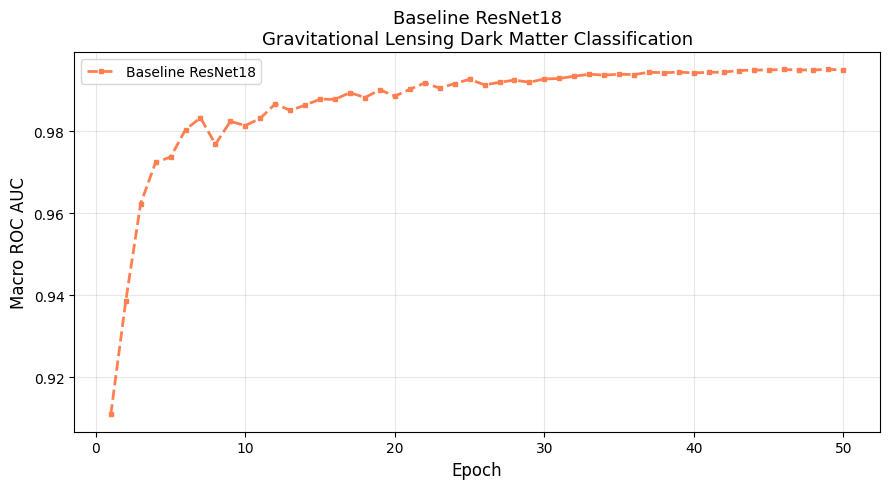


=== Final Summary ===
Baseline ResNet18:         0.9950


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
epochs = range(1, TOTAL_EPOCHS + 1)


ax.plot(epochs, baseline_aucs, label='Baseline ResNet18',
        color='coral', lw=2, ls='--', marker='s', markersize=3)


ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Macro ROC AUC', fontsize=12)
ax.set_title('Baseline ResNet18\n'
             'Gravitational Lensing Dark Matter Classification', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n=== Final Summary ===')
print(f'Baseline ResNet18:         {max(baseline_aucs):.4f}')